# 公式チュートリアル 01 — Brief Tour of E-Cell4 Simulations
> 出典: https://ecell4.e-cell.org/tutorials/tutorial01.html （公式コードの移植・描画は matplotlib）

E-Cell4 の最短ワークフロー: **モデルを書く → 初期値と体積を与えて `run_simulation` → ソルバを差し替える**。

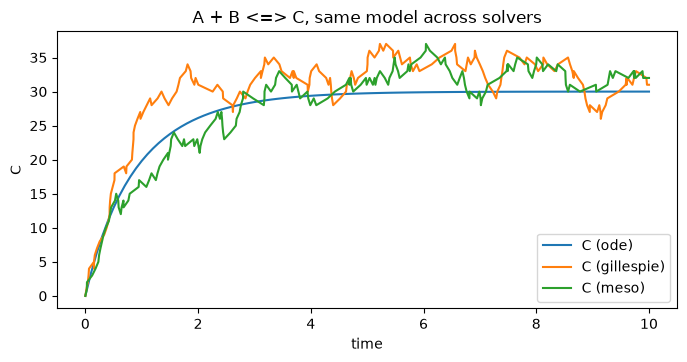

In [1]:
import warnings; warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
from ecell4.prelude import *

with reaction_rules():
    A + B > C | 0.01
    C > A + B | 0.3
m1 = get_model()

fig, ax = plt.subplots(figsize=(8,3.6))
for solver in ['ode', 'gillespie', 'meso']:
    a = run_simulation(10.0, model=m1, y0={'A':60,'B':60}, volume=1.0, solver=solver, species_list=['C']).as_array()
    ax.plot(a[:,0], a[:,1], label=f'C ({solver})')
ax.set_xlabel('time'); ax.set_ylabel('C'); ax.legend(); ax.set_title('A + B <=> C, same model across solvers'); plt.show()

**要点**: 同じモデル `m1` を `solver=` を変えるだけで ODE / Gillespie / meso で解ける。空間版は `species_attributes()` で
`radius`/`D` を付け、`structures=` に `Sphere` 等を渡し `solver='spatiocyte'` にする（tut09/10 参照）。